In [125]:
import math

import matplotlib.pyplot as plt
import numpy as np

from scipy import ndimage as ndi
from scipy import signal as signal

from skimage import data
from skimage.util import img_as_float
from skimage.filters import gabor_kernel

from PIL import Image

# Что есть октава для bandpass фильтра?

## Матчасть

Формулы про bandwidth и Q: <a href="./refs/Bandwidth_in_Octaves_vs_Q_in_Bandpass_Filters.pdf">BANDWIDTH IN OCTAVES VERSUS Q IN BANDPASS FILTERS</a>

Самое главное, что \$f_0\$ - это среднее геометрическое между \$f_1\$ и \$f_2\$ (\$f_0=\sqrt{f_0f_1})\$). Это значит, что \$(f_2 - f_0) > (f_0 - f_1)\$. Т.е. правый хвост будет больше!

Диалог с AI: <a href="./refs/AI-Dialog2_SpatialFrequencyAndCyclesPerPixel.pdf">What does it mean "The bandwidth captured by the filter" & What does it mean "Spatial frequency of the harmonic function.
Specified in pixels" relative to gabor filter</a>

In [126]:
f0 = 1_000
bandwidth = 1 # octaves
f1 = f0 / math.sqrt(2**bandwidth)
f2 = 2 * f1
bandwidth_hz = f2 - f1
f0, f1, f2, bandwidth_hz

(1000, 707.1067811865474, 1414.2135623730949, 707.1067811865474)

In [127]:
f0 = 10_000
bandwidth = 1 # octaves
f1 = f0 / math.sqrt(2**bandwidth)
f2 = 2 * f1
bandwidth_hz = f2 - f1
f0, f1, f2, bandwidth_hz

(10000, 7071.067811865475, 14142.13562373095, 7071.067811865475)

# Параметры Габор фильтров

## Матчасть

Формулы про bandwidth и Q: <a href="./refs/Bandwidth_in_Octaves_vs_Q_in_Bandpass_Filters.pdf">BANDWIDTH IN OCTAVES VERSUS Q IN BANDPASS FILTERS</a>

Самое главное, что \$f_0\$ - это среднее геометрическое между \$f_1\$ и \$f_2\$ (\$f_0=\sqrt{f_0f_1})\$). Это значит, что \$(f_2 - f_0) > (f_0 - f_1)\$. Т.е. правый хвост будет больше!

Диалог с AI: <a href="./refs/AI-Dialog2_SpatialFrequencyAndCyclesPerPixel.pdf">What does it mean "The bandwidth captured by the filter" & What does it mean "Spatial frequency of the harmonic function.
Specified in pixels" relative to gabor filter</a>

Tutorial 74 - What are Gabor filters and how to use them to generate features for machine learning? https://www.youtube.com/watch?v=yn1NUwaxhZg  
Tutorial 75 - Extracting features for machine learning using Gabor filter banks https://www.youtube.com/watch?v=ywyomOyXpxg    
<a href="./refs/AI-Dialog3_HalfMagnitudeBandwidth.pdf">Про half-magnitude bandwidth</a>  
<a href="./refs/AI-Dialog4_BandwidthEffect.pdf">Как влияет bandwidth на размер фильтра и на то, что фильтр будет отлавливать</a>

## theta, frequency

In [30]:
kernels = []
kernel_names = []

for theta in range(4):
    theta = theta / 4.0 * np.pi
    
    for frequency in (0.1, 0.25, 0.5): # cycles/pixel
        kernel = gabor_kernel(frequency, theta=theta)
        kernel = np.real(kernel)
        kernels.append(kernel)
        kernel_names.append(f'θ={theta * 180 / np.pi:.0f}, f={frequency}, sz={kernel.shape[0]}x{kernel.shape[1]}')

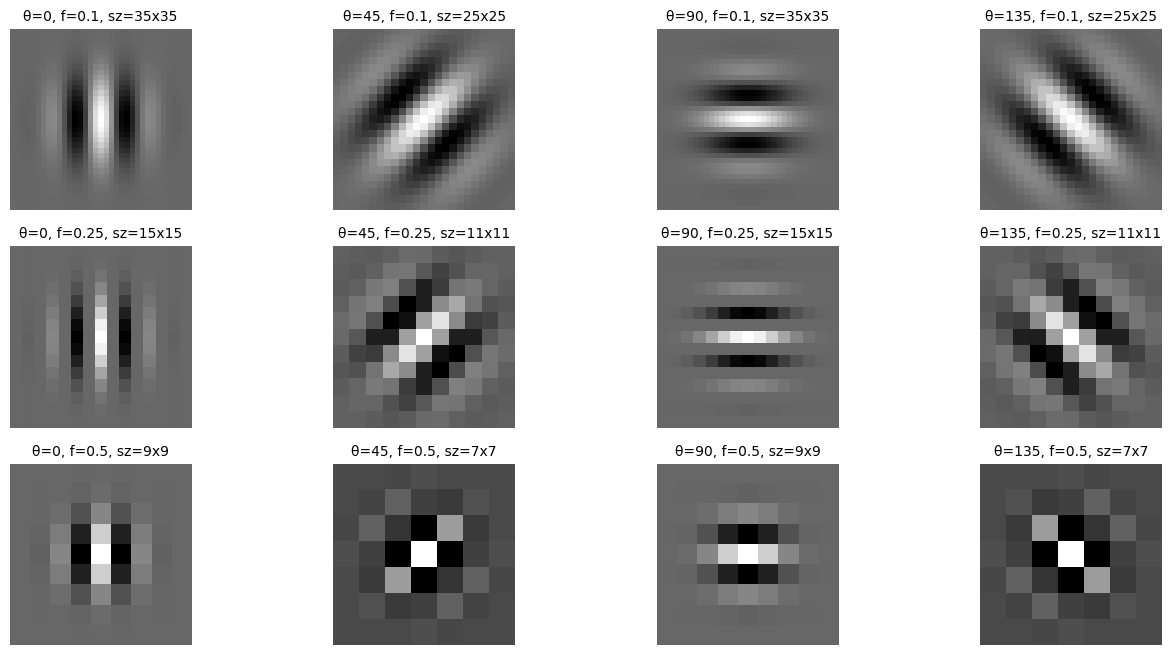

In [31]:
kernels_per_column = 3
fig, axes = plt.subplots(kernels_per_column, int(np.ceil(len(kernels) / kernels_per_column)), subplot_kw={'yticks': [], 'xticks': []})
for ax in axes.ravel(): ax.set_axis_off()
fig.set_figwidth(16)
fig.set_figheight(8)

for kernel, kernel_name, ax in zip(kernels, kernel_names, axes.T.ravel()):
    ax.set_title(f'{kernel_name}', fontdict=dict(fontsize=10))
    ax.imshow(kernel, cmap='gray')

In [53]:
np.round(kernels[2], 2)

array([[ 0.  , -0.  ,  0.  , -0.  ,  0.  , -0.  ,  0.  , -0.  ,  0.  ],
       [ 0.  , -0.  ,  0.  , -0.  ,  0.  , -0.  ,  0.  , -0.  ,  0.  ],
       [ 0.  , -0.  ,  0.01, -0.02,  0.03, -0.02,  0.01, -0.  ,  0.  ],
       [ 0.  , -0.  ,  0.02, -0.06,  0.08, -0.06,  0.02, -0.  ,  0.  ],
       [ 0.  , -0.  ,  0.03, -0.08,  0.13, -0.08,  0.03, -0.  ,  0.  ],
       [ 0.  , -0.  ,  0.02, -0.06,  0.08, -0.06,  0.02, -0.  ,  0.  ],
       [ 0.  , -0.  ,  0.01, -0.02,  0.03, -0.02,  0.01, -0.  ,  0.  ],
       [ 0.  , -0.  ,  0.  , -0.  ,  0.  , -0.  ,  0.  , -0.  ,  0.  ],
       [ 0.  , -0.  ,  0.  , -0.  ,  0.  , -0.  ,  0.  , -0.  ,  0.  ]])

Видно, что с ростом частоты (0.1->0.5) уменьшается размер фильтра с 35х35 до 9х9. Это из-за того, что для того, чтобы поймать low-frequency нужно больше данных, а высокочастотность можно поймать и на очень ограниченном участке.

## theta, sigma

In [40]:
kernels = []
kernel_names = []
frequency = 0.1

for theta in range(4):
    theta = theta / 4.0 * np.pi

    for sigma in (2, 4, 8):
        kernel = gabor_kernel(frequency, theta=theta, sigma_x=sigma, sigma_y=sigma)
        kernel = np.real(kernel)
        kernels.append(kernel)
        kernel_names.append(f'θ={theta * 180 / np.pi:.0f}, f={frequency}, σ={sigma}, sz={kernel.shape[0]}x{kernel.shape[1]}')

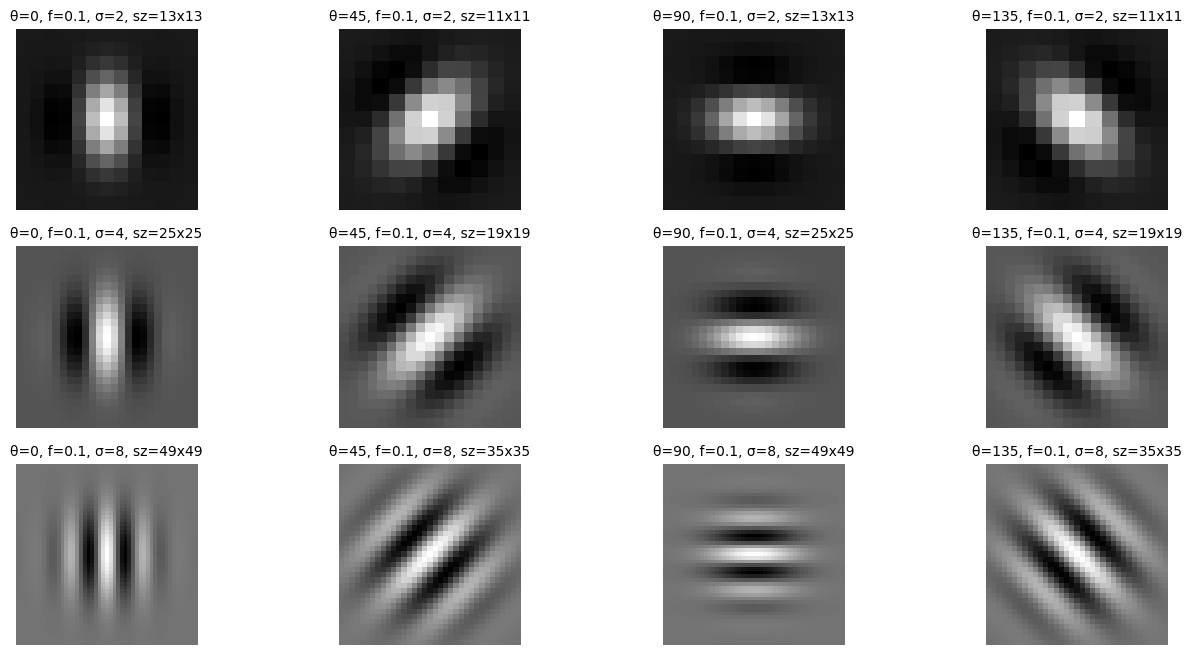

In [41]:
kernels_per_column = 3
fig, axes = plt.subplots(kernels_per_column, int(np.ceil(len(kernels) / kernels_per_column)), subplot_kw={'yticks': [], 'xticks': []})
for ax in axes.ravel(): ax.set_axis_off()
fig.set_figwidth(16)
fig.set_figheight(8)

for kernel, kernel_name, ax in zip(kernels, kernel_names, axes.T.ravel()):
    ax.set_title(f'{kernel_name}', fontdict=dict(fontsize=10))
    ax.imshow(kernel, cmap='gray')

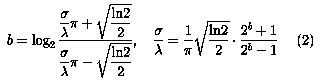

## frequency, sigma

In [57]:
kernels = []
kernel_names = []
theta = 0
c = np.sqrt(np.log(2) / 2)

for frequency in (0.1, 0.25, 0.5): # cycles/pixel
    for sigma in (2, 4, 8):
        kernel = gabor_kernel(frequency, theta=theta, sigma_x=sigma, sigma_y=sigma)
        kernel = np.real(kernel)
        kernels.append(kernel)
        x = sigma * frequency # lambda = 1/frequency
        bandwidth = np.log2((x * np.pi + c) / (x * np.pi - c))
        kernel_names.append(f'f={frequency}, σ={sigma} => b={bandwidth:.1f}, sz={kernel.shape[0]}x{kernel.shape[1]}')

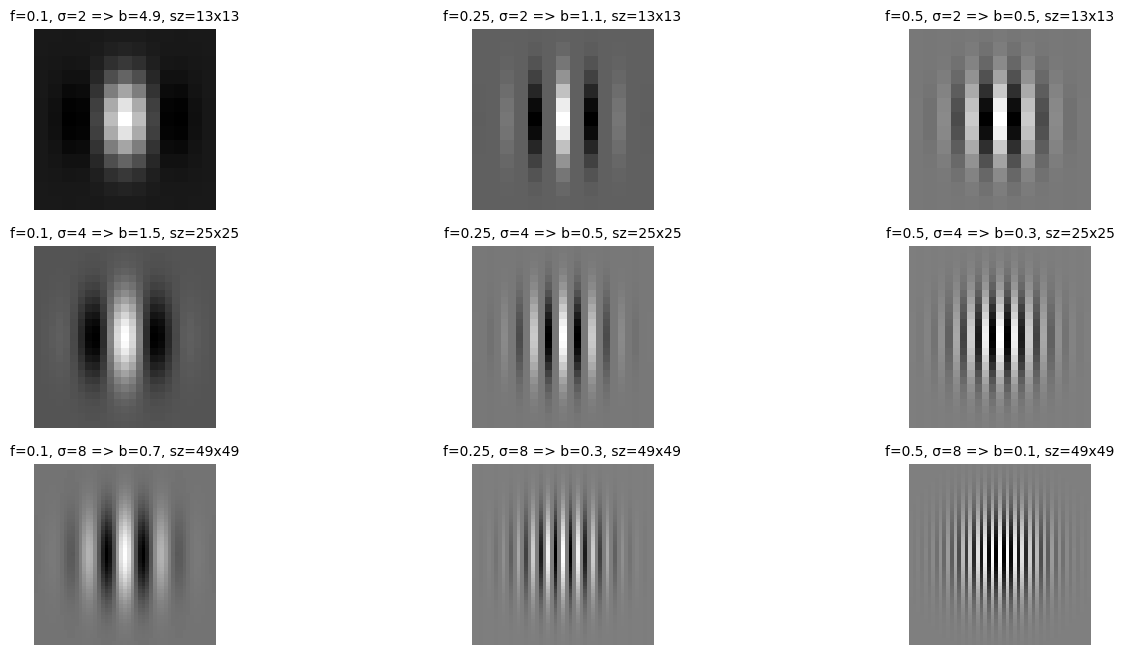

In [58]:
kernels_per_column = 3
fig, axes = plt.subplots(kernels_per_column, int(np.ceil(len(kernels) / kernels_per_column)), subplot_kw={'yticks': [], 'xticks': []})
for ax in axes.ravel(): ax.set_axis_off()
fig.set_figwidth(16)
fig.set_figheight(8)

for kernel, kernel_name, ax in zip(kernels, kernel_names, axes.T.ravel()):
    ax.set_title(f'{kernel_name}', fontdict=dict(fontsize=10))
    ax.imshow(kernel, cmap='gray')

## frequency, bandwidth

In [62]:
kernels = []
kernel_names = []
theta = 0

for frequency in (0.1, 0.25, 0.5): # cycles/pixel
    for bandwidth in (0.7, 1.5, 4.9):
        kernel = gabor_kernel(frequency, theta=theta, bandwidth=bandwidth)
        kernel = np.real(kernel)
        kernels.append(kernel)
        kernel_names.append(f'f={frequency}, b={bandwidth:.1f} => sz={kernel.shape[0]}x{kernel.shape[1]}')

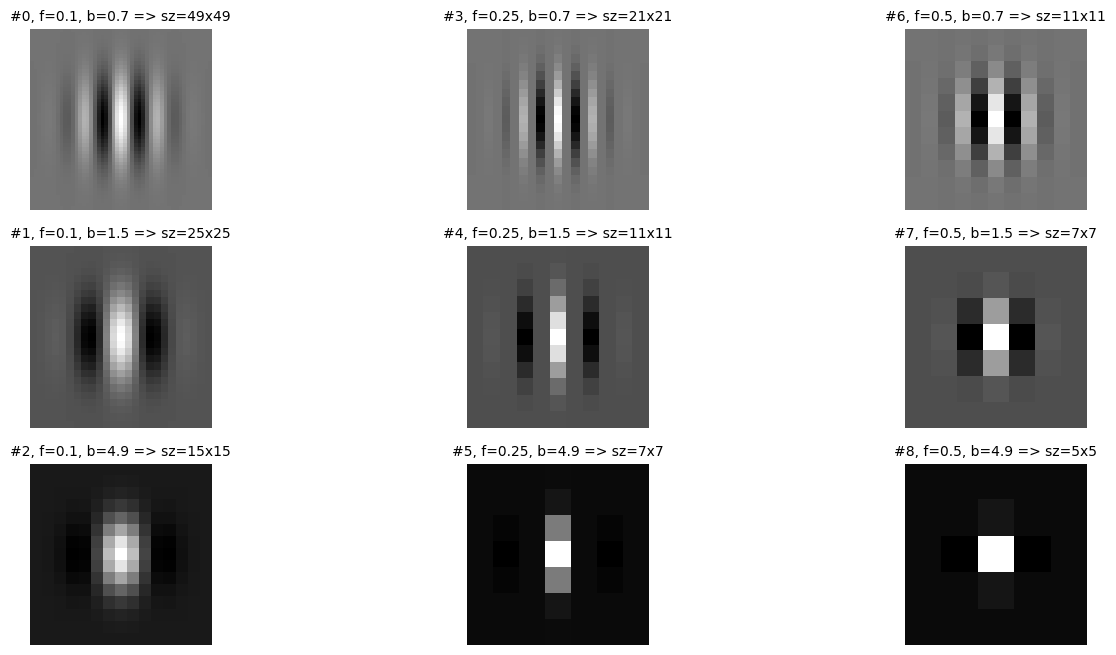

In [76]:
kernels_per_column = 3
fig, axes = plt.subplots(kernels_per_column, int(np.ceil(len(kernels) / kernels_per_column)), subplot_kw={'yticks': [], 'xticks': []})
for ax in axes.ravel(): ax.set_axis_off()
fig.set_figwidth(16)
fig.set_figheight(8)

for i, (kernel, kernel_name, ax) in enumerate(zip(kernels, kernel_names, axes.T.ravel())):
    ax.set_title(f'#{i}, {kernel_name}', fontdict=dict(fontsize=10))
    ax.imshow(kernel, cmap='gray')

In [66]:
np.round(kernels[-1], 2)

array([[ 0.  , -0.  ,  0.  , -0.  ,  0.  ],
       [ 0.  , -0.  ,  0.04, -0.  ,  0.  ],
       [ 0.  , -0.04,  0.99, -0.04,  0.  ],
       [ 0.  , -0.  ,  0.04, -0.  ,  0.  ],
       [ 0.  , -0.  ,  0.  , -0.  ,  0.  ]])

# Как работают фильтры

## Тестовая картинка

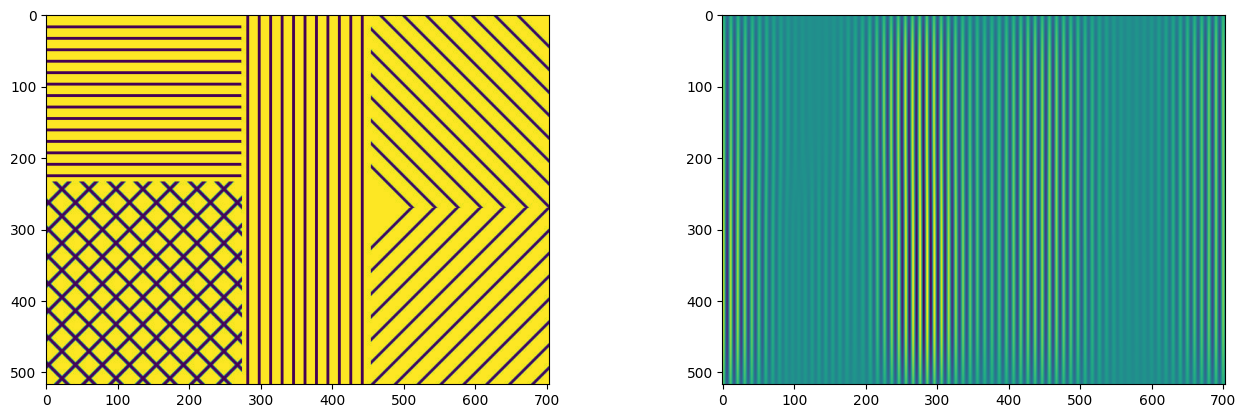

In [116]:
image = Image.open('./img/synthetic.jpg')
image = image.convert('L')
convolved = signal.convolve(np.array(image), kernels[0], mode='same')
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
ax1.imshow(np.array(image));
ax2.imshow(convolved);

## Высокий freq с разным bandwidth

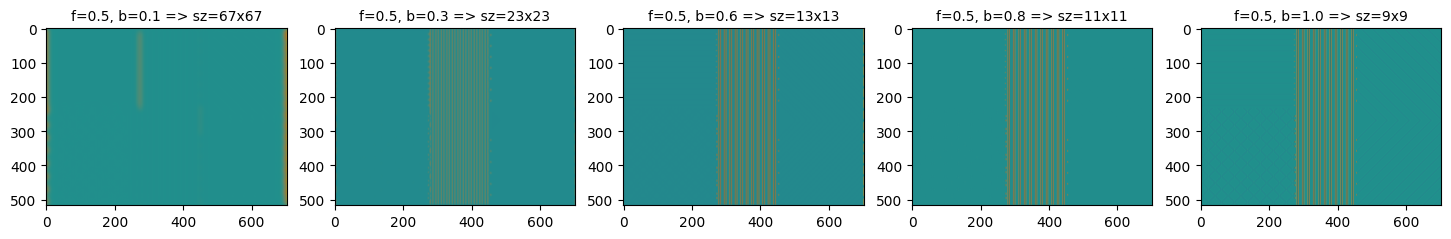

In [117]:
kernels = []
kernel_names = []
theta = 0
frequency = 0.5

for bandwidth in np.linspace(0.1, 1, 5):
    kernel = gabor_kernel(frequency, theta=theta, bandwidth=bandwidth)
    kernel = np.real(kernel)
    kernels.append(kernel)
    kernel_names.append(f'f={frequency}, b={bandwidth:.1f} => sz={kernel.shape[0]}x{kernel.shape[1]}')

fig, axes = plt.subplots(1, len(kernels))
fig.set_figwidth(18)

for kernel, kernel_name, ax in zip(kernels, kernel_names, axes.ravel()):
    convolved = signal.convolve(np.array(image), kernel, mode='same')
    ax.set_title(kernel_name, fontdict=dict(fontsize=10))
    ax.imshow(convolved);

## Низкий freq с разным bandwidth

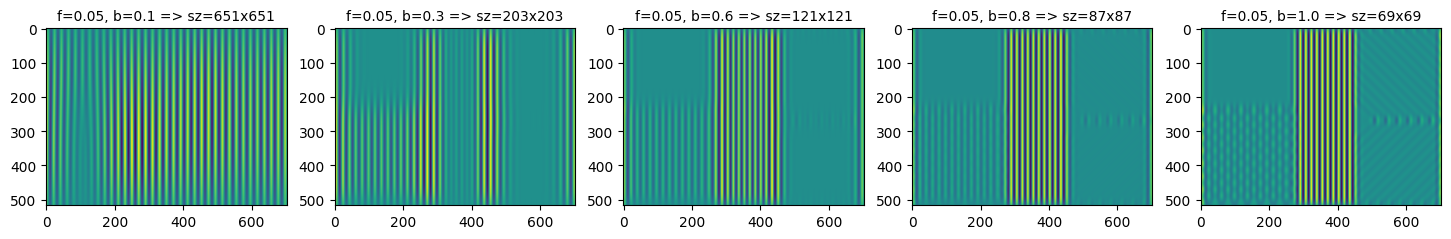

In [123]:
kernels = []
kernel_names = []
theta = 0
frequency = 0.05

for bandwidth in np.linspace(0.1, 1, 5):
    kernel = gabor_kernel(frequency, theta=theta, bandwidth=bandwidth)
    kernel = np.real(kernel)
    kernels.append(kernel)
    kernel_names.append(f'f={frequency}, b={bandwidth:.1f} => sz={kernel.shape[0]}x{kernel.shape[1]}')

fig, axes = plt.subplots(1, len(kernels))
fig.set_figwidth(18)

for kernel, kernel_name, ax in zip(kernels, kernel_names, axes.ravel()):
    convolved = signal.convolve(np.array(image), kernel, mode='same')
    ax.set_title(kernel_name, fontdict=dict(fontsize=10))
    ax.imshow(convolved);

## Выводы

Получается, что чем больше bandwidth, тем менее разборчивым по частоте становится фильтр. Он как бы говорит: "Я буду реагировать на заданную частоту, ну и плюс-минус на рядом лежащие". Поэтому я смогу сказать, где точно в пространстве находится искомая частота, но правда это будет замусорено другими частотами (типа не пропущу частоту, но будет много ложных срабатываний по частоте).  

Если bandwidth меньше, то фильтр как бы говорит "Так, мне нужно больше данных, чтобы убедиться, что искомая частота тут. Я не хочу пропускать лишние, мусорные частоты, поэтому я буду смотреть намного дальше по всем сторонам (искать паттерн), чтобы убедиться, что это именно эта частота. Правда при этом местоположение сложнее определить, т.к. я буду реагировать только на повторяющиеся вещи, раз (тебе же нужно убедиться, что частота есть железобетенно)!"

Короче, про bandwidth можно думать, как про повторения или регулярность. Хочется ли их отлавливать (малый bandwidth), или нужны только единичные случаи (высокий bandwidth).

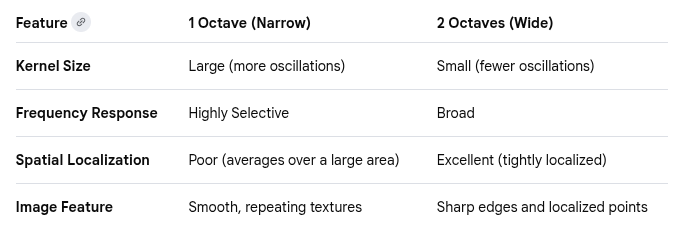